# PyTorch Fundamentals: The Building Blocks of Deep Learning

## What We'll Learn

You've learned about tensors, matrix operations, and what neural networks are conceptually. Now we need to understand **how PyTorch helps us build and train them**.

This notebook covers the essential PyTorch ecosystem:

1. **Autograd** - Automatic differentiation (the magic behind `.backward()`)
2. **nn.Parameter** - How PyTorch tracks trainable parameters
3. **nn.Module** - The foundation for building neural network components
4. **Training Loops** - The standard structure for training models
5. **Custom Layers** - Building your own neural network components

By the end, you'll understand the PyTorch way of building and training neural networks from the ground up.

## Why This Matters

PyTorch provides three critical capabilities:

1. **Automatic gradient computation** - No more manual derivative calculations!
2. **Modular architecture** - Build complex networks from simple, reusable components
3. **Training infrastructure** - Standard patterns for optimization and parameter updates

Understanding these tools is essential before diving into backpropagation and neural network training.

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

from aiml_notebooks import get_device, set_seed

Execute a quick computation.

In [2]:
%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [3]:
set_seed(42)

Configure device (MPS > CUDA > CPU).

In [4]:
device = get_device()
print(f"Using device: {device}")

Using CPU
Using device: cpu


## 1. Autograd: Automatic Differentiation

### What is Autograd?

**Autograd** is PyTorch's automatic differentiation engine. It tracks every operation you perform on tensors and builds a **computational graph** behind the scenes. When you call `.backward()`, it traverses this graph in reverse to compute gradients automatically.

This is the magic that makes neural network training feasible - you don't have to manually compute derivatives!

### Simple Example: Computing Gradients

Let's compute the gradient of $y = x^2$ with respect to $x$.

Mathematically: $\frac{dy}{dx} = 2x$

At $x = 3$, the gradient should be $2 \times 3 = 6$.

In [5]:
# Create a tensor and tell PyTorch to track operations on it
x = torch.tensor([3.0], requires_grad=True)

# Perform computation
y = x ** 2

print(f"x = {x}")
print(f"y = {y}")
print(f"x.requires_grad = {x.requires_grad}")
print(f"y.requires_grad = {y.requires_grad}")

x = tensor([3.], requires_grad=True)
y = tensor([9.], grad_fn=<PowBackward0>)
x.requires_grad = True
y.requires_grad = True


Notice that `y.requires_grad = True` automatically - PyTorch knows that since `y` depends on `x` (which requires grad), it should also track `y`'s operations.

### The .backward() Method

Now we compute the gradient by calling `.backward()` on the output.

In [6]:
# Compute gradients
y.backward()

# Access the gradient of y with respect to x
print(f"dy/dx at x=3: {x.grad}")
print(f"Expected: {2 * 3}")

dy/dx at x=3: tensor([6.])
Expected: 6


Perfect! PyTorch computed the derivative automatically.

**Key insight**: `.backward()` computes gradients and stores them in the `.grad` attribute of each tensor that has `requires_grad=True`.

### Gradient Accumulation

An important detail: **gradients accumulate** by default. If you call `.backward()` multiple times, gradients add up.

This is why we need to zero gradients before each training step!

In [7]:
# Create new tensor
x = torch.tensor([3.0], requires_grad=True)

# First backward pass
y = x ** 2
y.backward()
print(f"After 1st backward: x.grad = {x.grad}")

# Second backward pass WITHOUT zeroing gradients
y = x ** 2
y.backward()
print(f"After 2nd backward: x.grad = {x.grad}")

# Now zero and try again
x.grad.zero_()
y = x ** 2
y.backward()
print(f"After zero + backward: x.grad = {x.grad}")

After 1st backward: x.grad = tensor([6.])
After 2nd backward: x.grad = tensor([12.])
After zero + backward: x.grad = tensor([6.])


See how gradients doubled? This accumulation is **intentional** - it's useful for gradient accumulation across mini-batches. But for standard training, we must zero gradients each iteration.

### Computational Graphs and the Chain Rule

Let's see autograd handle a more complex function with multiple operations:

$$z = (x + 2)^2 \times 3$$

PyTorch will automatically apply the chain rule!

In [8]:
x = torch.tensor([1.0], requires_grad=True)

# Build computation step by step
a = x + 2          # a = 3
b = a ** 2         # b = 9
z = b * 3          # z = 27

print(f"x = {x.item()}")
print(f"z = {z.item()}")

# Compute gradient
z.backward()
print(f"dz/dx = {x.grad.item()}")

x = 1.0
z = 27.0
dz/dx = 18.0


Let's verify this manually using the chain rule:

$$\frac{dz}{dx} = \frac{dz}{db} \cdot \frac{db}{da} \cdot \frac{da}{dx}$$

- $\frac{dz}{db} = 3$
- $\frac{db}{da} = 2a = 2(x+2) = 2 \times 3 = 6$
- $\frac{da}{dx} = 1$

So: $\frac{dz}{dx} = 3 \times 6 \times 1 = 18$ ✓

### Visualizing the Computational Graph

Here's what PyTorch built behind the scenes:

```
x (requires_grad=True)
  |
  v (+ operation)
a = x + 2
  |
  v (** operation)
b = a ** 2
  |
  v (* operation)
z = b * 3
```

When you call `z.backward()`, PyTorch:
1. Starts at `z`
2. Computes gradients backward through each operation
3. Accumulates them in the `.grad` attribute

### Detaching from the Graph

Sometimes you want to compute values without tracking gradients. Two common approaches:

In [9]:
x = torch.tensor([2.0], requires_grad=True)

# Method 1: .detach() - creates a new tensor without gradient tracking
y = x ** 2
y_detached = y.detach()
print(f"y.requires_grad = {y.requires_grad}")
print(f"y_detached.requires_grad = {y_detached.requires_grad}")

# Method 2: torch.no_grad() context - useful for evaluation/inference
with torch.no_grad():
    z = x ** 3
    print(f"z.requires_grad = {z.requires_grad}")

y.requires_grad = True
y_detached.requires_grad = False
z.requires_grad = False


**When to use this**:
- During evaluation/testing (saves memory)
- When computing metrics that shouldn't affect gradients
- When implementing certain algorithms that mix gradient and non-gradient computations

## 2. nn.Parameter: Trainable Tensors

### What Makes a Parameter Special?

A **Parameter** is a special type of tensor that:
1. Always has `requires_grad=True`
2. Automatically registers itself when assigned to an `nn.Module`
3. Shows up in `module.parameters()`

Think of Parameters as "this tensor should be learned during training."

### Creating Parameters

Let's see the difference between a regular tensor and a Parameter.

In [10]:
# Regular tensor with requires_grad
regular_tensor = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)

# Parameter (always requires_grad)
param = nn.Parameter(torch.tensor([1.0, 2.0, 3.0]))

print(f"Regular tensor type: {type(regular_tensor)}")
print(f"Parameter type: {type(param)}")
print(f"Regular tensor requires_grad: {regular_tensor.requires_grad}")
print(f"Parameter requires_grad: {param.requires_grad}")

Regular tensor type: <class 'torch.Tensor'>
Parameter type: <class 'torch.nn.parameter.Parameter'>
Regular tensor requires_grad: True
Parameter requires_grad: True


The key difference emerges when we use them in an `nn.Module` - we'll see this next!

## 3. nn.Module: The Foundation of Neural Networks

### What is nn.Module?

`nn.Module` is the base class for all neural network components in PyTorch. It provides:

1. **Automatic parameter registration** - Keeps track of all Parameters
2. **Device management** - Easy GPU/CPU transfer with `.to(device)`
3. **Training/eval modes** - Switch between training and inference behavior
4. **State management** - Save and load model weights
5. **Composability** - Build complex models from simple modules

Every model, layer, and component inherits from `nn.Module`.

### Your First Custom Layer

Let's build a simple linear layer from scratch: $y = Wx + b$

This performs the fundamental operation of neural networks!

In [11]:
class SimpleLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        # Initialize weight and bias as Parameters
        self.weight = nn.Parameter(torch.randn(out_features, in_features))
        self.bias = nn.Parameter(torch.randn(out_features))
    
    def forward(self, x):
        # y = xW^T + b (note the transpose!)
        return x @ self.weight.T + self.bias

Let's create and test our custom layer.

In [12]:
# Create layer: 3 input features -> 2 output features
layer = SimpleLinear(3, 2)

# Test with random input
x = torch.randn(5, 3)  # Batch of 5 samples, 3 features each
output = layer(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"\nWeight shape: {layer.weight.shape}")
print(f"Bias shape: {layer.bias.shape}")

Input shape: torch.Size([5, 3])
Output shape: torch.Size([5, 2])

Weight shape: torch.Size([2, 3])
Bias shape: torch.Size([2])


### Automatic Parameter Registration

Here's the magic - all Parameters are automatically registered!

In [13]:
# Access all parameters
for name, param in layer.named_parameters():
    print(f"{name}: shape {param.shape}")

# Count total parameters
total_params = sum(p.numel() for p in layer.parameters())
print(f"\nTotal parameters: {total_params}")

weight: shape torch.Size([2, 3])
bias: shape torch.Size([2])

Total parameters: 8


This automatic registration is crucial - optimizers use `model.parameters()` to know which tensors to update!

### Built-in Layers

PyTorch provides optimized implementations of common layers. Let's compare our custom layer to `nn.Linear`.

In [14]:
# PyTorch's built-in linear layer
builtin_layer = nn.Linear(3, 2)

# Same test
x = torch.randn(5, 3)
output = builtin_layer(x)

print(f"Output shape: {output.shape}")
print(f"\nBuilt-in layer parameters:")
for name, param in builtin_layer.named_parameters():
    print(f"{name}: shape {param.shape}")

Output shape: torch.Size([5, 2])

Built-in layer parameters:
weight: shape torch.Size([2, 3])
bias: shape torch.Size([2])


Same structure! The built-in version includes:
- Better initialization (Xavier/Kaiming)
- Optimized CUDA kernels
- Numerical stability improvements

**Best practice**: Use built-in layers when available, build custom ones only when needed.

### Nested Modules: Building Networks

The real power of `nn.Module` is **composability** - modules can contain other modules!

Let's build a simple 2-layer network.

In [15]:
class TwoLayerNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        
        # Two linear layers
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Forward pass through both layers with ReLU activation
        x = self.layer1(x)
        x = F.relu(x)  # Activation function
        x = self.layer2(x)
        return x

Display the output.

In [16]:
# Create network: 10 inputs -> 20 hidden -> 3 outputs
model = TwoLayerNet(10, 20, 3)

# Test
x = torch.randn(8, 10)  # Batch of 8 samples
output = model(x)

print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

# Parameters are automatically collected from nested modules!
print(f"\nAll parameters:")
for name, param in model.named_parameters():
    print(f"{name}: shape {param.shape}")

total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params}")

Input shape: torch.Size([8, 10])
Output shape: torch.Size([8, 3])

All parameters:
layer1.weight: shape torch.Size([20, 10])
layer1.bias: shape torch.Size([20])
layer2.weight: shape torch.Size([3, 20])
layer2.bias: shape torch.Size([3])

Total parameters: 283


Notice how `model.parameters()` automatically includes parameters from both `layer1` and `layer2` - no manual tracking needed!

## 4. The Training Loop Structure

### The Five Essential Steps

Every neural network training loop follows the same pattern:

1. **Forward pass** - Compute predictions
2. **Compute loss** - Measure how wrong the predictions are
3. **Zero gradients** - Clear old gradients
4. **Backward pass** - Compute gradients via backpropagation
5. **Update parameters** - Adjust weights using optimizer

Let's see each step in detail.

### Step-by-Step Example

We'll train a simple model to learn the function $y = 2x + 1$.

In [17]:
# Create synthetic data: y = 2x + 1
x_train = torch.randn(100, 1)
y_train = 2 * x_train + 1 + 0.1 * torch.randn(100, 1)  # Add small noise

print(f"Training data shapes: x={x_train.shape}, y={y_train.shape}")

Training data shapes: x=torch.Size([100, 1]), y=torch.Size([100, 1])


Create a simple model (just one linear layer).

In [18]:
# Simple linear model: y = wx + b
model = nn.Linear(1, 1)

# Create optimizer
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

# Loss function
criterion = nn.MSELoss()

print("Initial parameters:")
for name, param in model.named_parameters():
    print(f"{name}: {param.data}")

Initial parameters:
weight: tensor([[-0.1574]])
bias: tensor([0.7073])


### Single Training Step

Let's execute one iteration manually to see each step clearly.

In [19]:
# Step 1: Forward pass
predictions = model(x_train)
print(f"1. Forward pass: predictions.shape = {predictions.shape}")

# Step 2: Compute loss
loss = criterion(predictions, y_train)
print(f"2. Compute loss: {loss.item():.4f}")

# Step 3: Zero gradients (important!)
optimizer.zero_grad()
print(f"3. Zero gradients: weight.grad = {model.weight.grad}")

# Step 4: Backward pass
loss.backward()
print(f"4. Backward pass: weight.grad = {model.weight.grad.item():.4f}")

# Step 5: Update parameters
old_weight = model.weight.data.clone()
optimizer.step()
print(f"5. Update parameters:")
print(f"   Old weight: {old_weight.item():.4f}")
print(f"   New weight: {model.weight.data.item():.4f}")
print(f"   Change: {(model.weight.data - old_weight).item():.4f}")

1. Forward pass: predictions.shape = torch.Size([100, 1])
2. Compute loss: 4.5837
3. Zero gradients: weight.grad = None
4. Backward pass: weight.grad = -4.2587
5. Update parameters:
   Old weight: -0.1574
   New weight: -0.1148
   Change: 0.0426


### Complete Training Loop

Now let's train for multiple epochs and watch the model improve!

In [20]:
# Reset model
model = nn.Linear(1, 1)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# Track loss history
losses = []

# Training loop
epochs = 100
for epoch in range(epochs):
    # 1. Forward pass
    predictions = model(x_train)
    
    # 2. Compute loss
    loss = criterion(predictions, y_train)
    
    # 3. Zero gradients
    optimizer.zero_grad()
    
    # 4. Backward pass
    loss.backward()
    
    # 5. Update parameters
    optimizer.step()
    
    # Record loss
    losses.append(loss.item())
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

print("\nFinal parameters:")
print(f"Weight: {model.weight.data.item():.4f} (target: 2.0)")
print(f"Bias: {model.bias.data.item():.4f} (target: 1.0)")

Epoch 20/100, Loss: 2.6623
Epoch 40/100, Loss: 1.3291
Epoch 60/100, Loss: 0.6656
Epoch 80/100, Loss: 0.3352
Epoch 100/100, Loss: 0.1706

Final parameters:
Weight: 1.6801 (target: 2.0)
Bias: 0.7150 (target: 1.0)


Visualize the training progress.

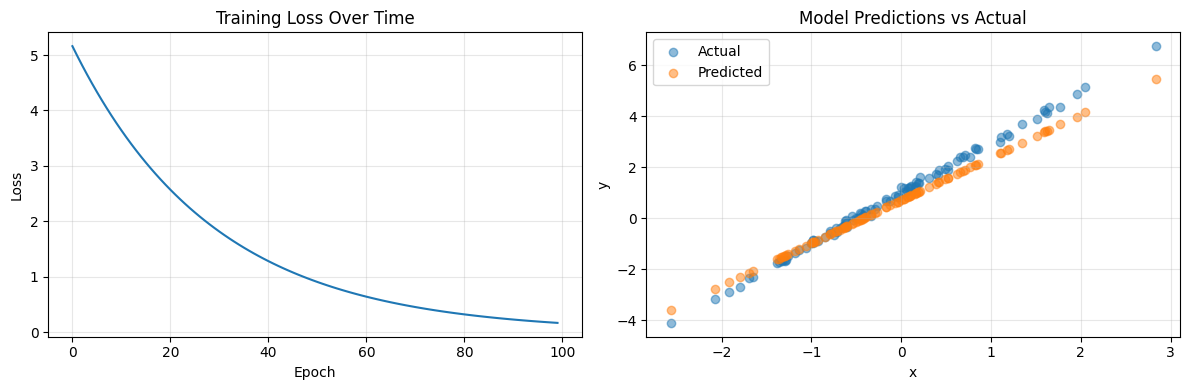

In [21]:
plt.figure(figsize=(12, 4))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)

# Predictions vs actual
plt.subplot(1, 2, 2)
with torch.no_grad():
    final_predictions = model(x_train)

plt.scatter(x_train.numpy(), y_train.numpy(), alpha=0.5, label='Actual')
plt.scatter(x_train.numpy(), final_predictions.numpy(), alpha=0.5, label='Predicted')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Model Predictions vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Perfect! The model learned the underlying relationship $y = 2x + 1$.

### Why Zero Gradients?

Let's see what happens if we forget to zero gradients!

In [22]:
# Create simple model
bad_model = nn.Linear(1, 1)
x_sample = torch.randn(10, 1)
y_sample = torch.randn(10, 1)

print("Gradients WITHOUT zeroing:")
for i in range(3):
    loss = criterion(bad_model(x_sample), y_sample)
    loss.backward()  # NO zero_grad()!
    print(f"Step {i+1}: weight.grad = {bad_model.weight.grad.item():.4f}")

print("\nGradients WITH zeroing:")
good_model = nn.Linear(1, 1)
for i in range(3):
    good_model.zero_grad()  # Clear gradients!
    loss = criterion(good_model(x_sample), y_sample)
    loss.backward()
    print(f"Step {i+1}: weight.grad = {good_model.weight.grad.item():.4f}")

Gradients WITHOUT zeroing:
Step 1: weight.grad = 0.0721
Step 2: weight.grad = 0.1443
Step 3: weight.grad = 0.2164

Gradients WITH zeroing:
Step 1: weight.grad = 0.0948
Step 2: weight.grad = 0.0948
Step 3: weight.grad = 0.0948


Without zeroing, gradients accumulate and grow unbounded - this would completely break training!

### Training vs Evaluation Mode

Some layers behave differently during training vs inference:
- **Dropout**: Randomly drops neurons during training, keeps all during eval
- **BatchNorm**: Uses batch statistics during training, running statistics during eval

Use `.train()` and `.eval()` to switch modes.

In [23]:
class ModelWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(10, 10)
        self.dropout = nn.Dropout(p=0.5)  # Drop 50% of neurons
    
    def forward(self, x):
        x = self.linear(x)
        x = self.dropout(x)
        return x

model = ModelWithDropout()
x = torch.ones(1, 10)

# Training mode - dropout active
model.train()
output_train = model(x)
print("Training mode (dropout active):")
print(output_train)

# Evaluation mode - no dropout
model.eval()
with torch.no_grad():
    output_eval = model(x)
print("\nEvaluation mode (no dropout):")
print(output_eval)

Training mode (dropout active):
tensor([[-0.0000,  0.0000, -0.2152, -0.2866, -0.0000, -0.9083, -0.0000, -1.0331,
          1.5613,  0.7509]], grad_fn=<MulBackward0>)

Evaluation mode (no dropout):
tensor([[-0.9020,  0.8808, -0.1076, -0.1433, -0.6045, -0.4541, -0.2507, -0.5165,
          0.7806,  0.3755]])


Notice the differences! Training mode randomly zeros out values, while eval mode keeps everything.

**Best practice**:
- Use `model.train()` during training
- Use `model.eval()` during validation/testing

## 5. Building a Custom Layer

### Layer with Custom Logic

Let's build a more interesting layer - a **linear layer with learnable activation scaling**:

$$y = \alpha \cdot \text{ReLU}(Wx + b)$$

Where $\alpha$ is a learned parameter!

In [24]:
class ScaledReLULinear(nn.Module):
    """Linear layer with learnable activation scaling."""
    
    def __init__(self, in_features, out_features):
        super().__init__()
        
        # Standard linear layer
        self.linear = nn.Linear(in_features, out_features)
        
        # Learnable scaling factor (one per output feature)
        self.alpha = nn.Parameter(torch.ones(out_features))
    
    def forward(self, x):
        # Apply linear transformation
        x = self.linear(x)
        
        # Apply ReLU
        x = F.relu(x)
        
        # Scale by learnable parameter
        x = x * self.alpha
        
        return x

Display the output.

In [25]:
# Create and test
layer = ScaledReLULinear(5, 3)

print("Parameters:")
for name, param in layer.named_parameters():
    print(f"{name}: shape {param.shape}")

# Test forward pass
x = torch.randn(2, 5)
output = layer(x)
print(f"\nInput shape: {x.shape}")
print(f"Output shape: {output.shape}")

Parameters:
alpha: shape torch.Size([3])
linear.weight: shape torch.Size([3, 5])
linear.bias: shape torch.Size([3])

Input shape: torch.Size([2, 5])
Output shape: torch.Size([2, 3])


Notice how both the linear layer's parameters AND our custom `alpha` parameter are registered!

### Verifying Gradient Flow

Let's verify that gradients flow through our custom layer correctly.

In [26]:
# Create layer and dummy target
layer = ScaledReLULinear(5, 3)
x = torch.randn(10, 5)
y_target = torch.randn(10, 3)

# Forward pass
output = layer(x)
loss = F.mse_loss(output, y_target)

# Backward pass
loss.backward()

# Check gradients
print("Gradients computed:")
for name, param in layer.named_parameters():
    has_grad = param.grad is not None
    grad_norm = param.grad.norm().item() if has_grad else 0.0
    print(f"{name}: has_grad={has_grad}, norm={grad_norm:.4f}")

Gradients computed:
alpha: has_grad=True, norm=0.2892
linear.weight: has_grad=True, norm=0.7148
linear.bias: has_grad=True, norm=0.4584


Perfect! Gradients flow through all parameters, including our custom `alpha`.

## 6. Putting It All Together: A Complete Example

### Building a Multi-Layer Classifier

Let's build a complete model using everything we've learned and train it on a real task: **binary classification**.

In [27]:
class BinaryClassifier(nn.Module):
    """Two-layer neural network for binary classification."""
    
    def __init__(self, input_size, hidden_size):
        super().__init__()
        
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size // 2)
        self.layer3 = nn.Linear(hidden_size // 2, 1)  # Single output for binary
        
        self.dropout = nn.Dropout(p=0.2)
    
    def forward(self, x):
        # Layer 1
        x = self.layer1(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Layer 2
        x = self.layer2(x)
        x = F.relu(x)
        x = self.dropout(x)
        
        # Output layer (no activation - we'll use BCEWithLogitsLoss)
        x = self.layer3(x)
        
        return x.squeeze(-1)  # Shape: (batch_size,)

### Generate Synthetic Data

Create two overlapping circular clusters.

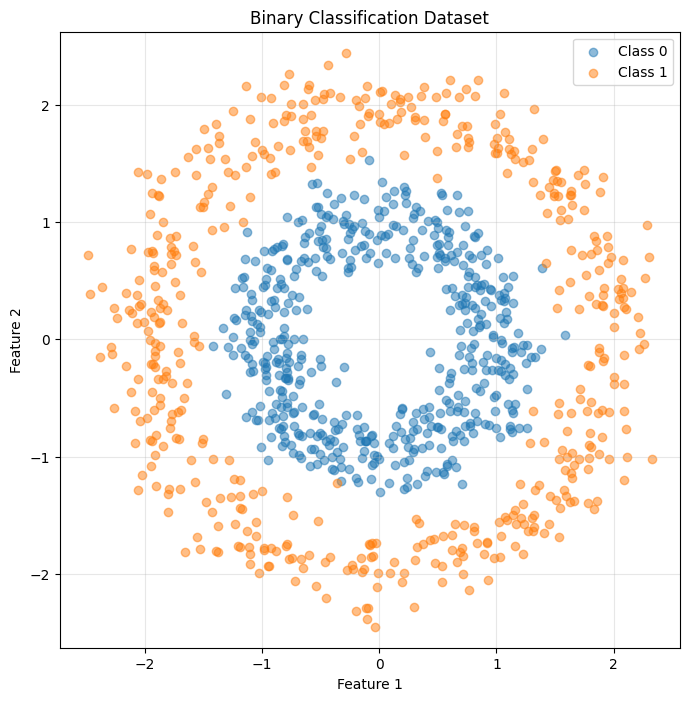

Dataset size: 1000
Features shape: torch.Size([1000, 2])
Labels shape: torch.Size([1000])


In [28]:
def generate_circle_data(n_samples=1000, noise=0.1):
    """Generate two concentric circles for binary classification."""
    
    # Inner circle (class 0)
    angles_inner = torch.rand(n_samples // 2) * 2 * np.pi
    radius_inner = 1.0 + noise * torch.randn(n_samples // 2)
    x_inner = torch.stack([
        radius_inner * torch.cos(angles_inner),
        radius_inner * torch.sin(angles_inner)
    ], dim=1)
    y_inner = torch.zeros(n_samples // 2)
    
    # Outer circle (class 1)
    angles_outer = torch.rand(n_samples // 2) * 2 * np.pi
    radius_outer = 2.0 + noise * torch.randn(n_samples // 2)
    x_outer = torch.stack([
        radius_outer * torch.cos(angles_outer),
        radius_outer * torch.sin(angles_outer)
    ], dim=1)
    y_outer = torch.ones(n_samples // 2)
    
    # Combine
    x = torch.cat([x_inner, x_outer], dim=0)
    y = torch.cat([y_inner, y_outer], dim=0)
    
    return x, y

# Generate data
x_data, y_data = generate_circle_data(n_samples=1000, noise=0.2)

# Visualize
plt.figure(figsize=(8, 8))
plt.scatter(x_data[y_data == 0, 0], x_data[y_data == 0, 1], alpha=0.5, label='Class 0')
plt.scatter(x_data[y_data == 1, 0], x_data[y_data == 1, 1], alpha=0.5, label='Class 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Binary Classification Dataset')
plt.legend()
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Dataset size: {len(x_data)}")
print(f"Features shape: {x_data.shape}")
print(f"Labels shape: {y_data.shape}")

### Train the Model

Complete training loop with everything we've learned!

In [29]:
# Create model
model = BinaryClassifier(input_size=2, hidden_size=64)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()  # Binary cross-entropy with logits

# Training loop
model.train()
losses = []
epochs = 200

for epoch in range(epochs):
    # 1. Forward pass
    logits = model(x_data)
    
    # 2. Compute loss
    loss = criterion(logits, y_data)
    
    # 3. Zero gradients
    optimizer.zero_grad()
    
    # 4. Backward pass
    loss.backward()
    
    # 5. Update parameters
    optimizer.step()
    
    # Record loss
    losses.append(loss.item())
    
    if (epoch + 1) % 50 == 0:
        # Compute accuracy
        with torch.no_grad():
            probs = torch.sigmoid(logits)
            predictions = (probs > 0.5).float()
            accuracy = (predictions == y_data).float().mean()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, Accuracy: {accuracy:.4f}")

Epoch 50/200, Loss: 0.0712, Accuracy: 0.9750


Epoch 100/200, Loss: 0.0334, Accuracy: 0.9880


Epoch 150/200, Loss: 0.0252, Accuracy: 0.9890


Epoch 200/200, Loss: 0.0222, Accuracy: 0.9930


### Visualize Results

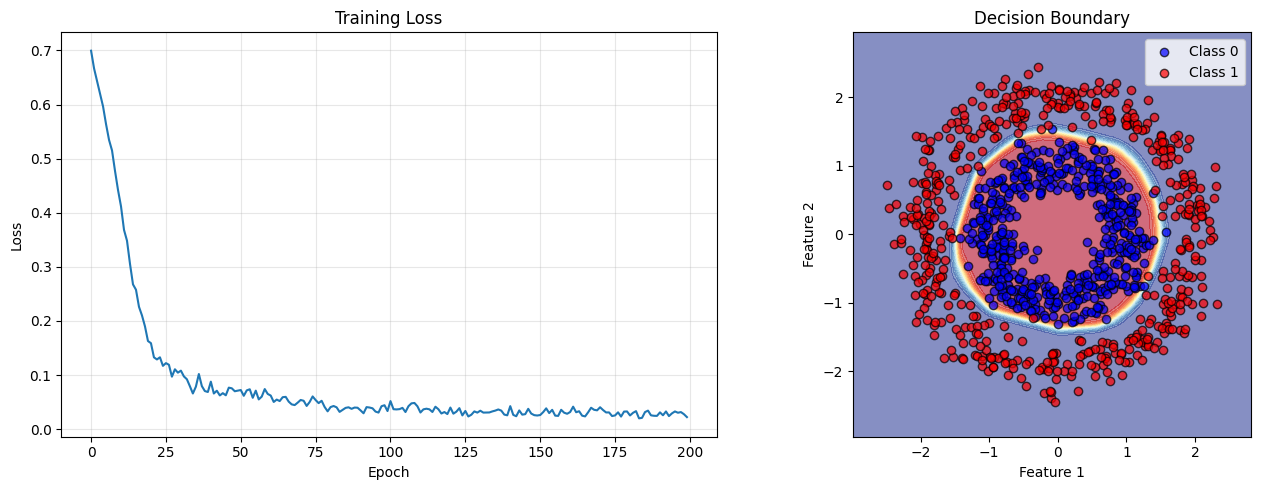

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(losses)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# Decision boundary
model.eval()
with torch.no_grad():
    # Create grid
    x_min, x_max = x_data[:, 0].min() - 0.5, x_data[:, 0].max() + 0.5
    y_min, y_max = x_data[:, 1].min() - 0.5, x_data[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    
    # Predict on grid
    logits = model(grid)
    probs = torch.sigmoid(logits)
    Z = probs.reshape(xx.shape).numpy()

# Plot decision boundary
axes[1].contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
axes[1].scatter(x_data[y_data == 0, 0], x_data[y_data == 0, 1], 
               c='blue', edgecolors='k', alpha=0.7, label='Class 0')
axes[1].scatter(x_data[y_data == 1, 0], x_data[y_data == 1, 1], 
               c='red', edgecolors='k', alpha=0.7, label='Class 1')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].set_title('Decision Boundary')
axes[1].legend()
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

Perfect! The model learned to separate the two circular classes.

**What we just did**:
1. Built a custom neural network using `nn.Module`
2. Trained it using the standard 5-step loop
3. Used autograd to compute gradients automatically
4. Visualized the learned decision boundary

## 7. Device Management

### Moving Models and Data to GPU

For large models and datasets, you'll want to use GPU acceleration. PyTorch makes this straightforward.

In [31]:
# Create model and data
model = BinaryClassifier(input_size=2, hidden_size=64)
x_sample = torch.randn(10, 2)

print(f"Device available: {device}")
print(f"Model device before: {next(model.parameters()).device}")
print(f"Data device before: {x_sample.device}")

# Move to device
model = model.to(device)
x_sample = x_sample.to(device)

print(f"\nModel device after: {next(model.parameters()).device}")
print(f"Data device after: {x_sample.device}")

# Now we can do computations on the device
output = model(x_sample)
print(f"\nOutput device: {output.device}")
print(f"Output shape: {output.shape}")

Device available: cpu
Model device before: cpu
Data device before: cpu

Model device after: cpu
Data device after: cpu

Output device: cpu
Output shape: torch.Size([10])


**Best practice**:
- Move model to device once: `model = model.to(device)`
- Move each batch to device in training loop: `x = x.to(device)`
- All tensors in a computation must be on the same device!

## 8. Saving and Loading Models

### State Dictionaries

PyTorch models can be saved and loaded using **state dictionaries** - Python dicts mapping parameter names to tensor values.

In [32]:
# Create and train a simple model
model = nn.Linear(5, 3)

# View state dict
print("State dictionary:")
for name, param in model.state_dict().items():
    print(f"{name}: shape {param.shape}")

# Save model
torch.save(model.state_dict(), '/tmp/model.pt')
print("\nModel saved!")

# Create new model and load weights
new_model = nn.Linear(5, 3)
new_model.load_state_dict(torch.load('/tmp/model.pt', weights_only=True))
print("Model loaded!")

# Verify they're the same
x_test = torch.randn(2, 5)
output1 = model(x_test)
output2 = new_model(x_test)
print(f"\nOutputs match: {torch.allclose(output1, output2)}")

State dictionary:
weight: shape torch.Size([3, 5])
bias: shape torch.Size([3])

Model saved!
Model loaded!

Outputs match: True


**Best practices**:
- Save state dict, not entire model: `torch.save(model.state_dict(), path)`
- Always create model architecture first, then load weights
- Use `.pt` or `.pth` extension by convention

## Key Takeaways

### 1. Autograd is the Foundation
- PyTorch builds computational graphs automatically
- `.backward()` computes all gradients via chain rule
- Gradients accumulate - remember to zero them!

### 2. nn.Module is How We Build Models
- Everything inherits from `nn.Module`
- Parameters are automatically registered and tracked
- Modules can contain other modules (composability)
- Use `model.parameters()` to access all trainable parameters

### 3. The Five-Step Training Loop
1. Forward pass → compute predictions
2. Compute loss → measure error
3. Zero gradients → `optimizer.zero_grad()`
4. Backward pass → `loss.backward()`
5. Update parameters → `optimizer.step()`

### 4. Train vs Eval Modes Matter
- Use `model.train()` during training
- Use `model.eval()` during validation/testing
- Affects dropout, batch normalization, etc.

### 5. Custom Layers are Easy
- Inherit from `nn.Module`
- Define parameters in `__init__`
- Implement `forward()` method
- Gradients flow automatically!

### 6. Device Management
- Move model once: `model.to(device)`
- Move data each batch: `x.to(device)`
- All tensors in computation must be on same device

## What's Next?

Now that you understand PyTorch's building blocks, you're ready to:

1. **Learn backpropagation deeply** - Build your own autograd engine to understand how `.backward()` actually works
2. **Build real neural networks** - CNNs, RNNs, Transformers
3. **Explore advanced training techniques** - Learning rate schedules, regularization, optimization algorithms

The PyTorch ecosystem you've learned here is the foundation for all modern deep learning!